In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys
from pathlib import Path

project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

from src.services.regression_model import MusicPopularityRegressor

In [2]:

# Carregar o dataset completo
df = pd.read_csv(project_root / "data" / "processed" / "dataset_clean.csv")
print(f"Dataset: {len(df)} musicas")

regressor = MusicPopularityRegressor(model_dir=project_root / "models")

FEATURES = [
    "danceability", "energy", "loudness_norm", "speechiness",
    "acousticness", "instrumentalness", "liveness", "valence", "tempo",
]

print(f"\n Features usadas pela IA: {FEATURES}")

Dataset: 89740 musicas

 Features usadas pela IA: ['danceability', 'energy', 'loudness_norm', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo']


In [17]:
np.random.seed(55)
sample = df.sample(15).reset_index(drop=True)

display(sample[["track_name", "artists", "track_genre"] + FEATURES])

,track_name,artists,track_genre,danceability,energy,loudness_norm,speechiness,acousticness,instrumentalness,liveness,valence,tempo
0,Arson,Ben Lukas Boysen;Paul Emmerich,idm,0.172,0.282,0.580286,0.0362,0.857000,0.817000,0.1160,0.0704,109.930
1,Climb High,Brookes Brothers;Danny Byrd,drum-and-bass,0.460,0.587,0.732349,0.0520,0.000997,0.069000,0.1300,0.1450,173.997
2,In the Minds of Evil,Deicide,black-metal,0.535,0.889,0.813569,0.0533,0.000099,0.410000,0.3290,0.3270,97.493
3,Get Innocuous! - Soulwax Remix,LCD Soundsystem;Soulwax,alt-rock,0.667,0.997,0.808298,0.0457,0.074500,0.744000,0.2410,0.6930,117.999
4,Count On Me,Hogland;Charlie South,deep-house,0.396,0.852,0.800344,0.2430,0.177000,0.000000,0.0776,0.3740,189.640
5,Dick'taphone,Kevin Bloody Wilson,comedy,0.745,0.509,0.636461,0.1660,0.322000,0.000024,0.4330,0.8320,120.213
6,Baki Rap. El Campeón,MegaR,anime,0.642,0.849,0.783641,0.4230,0.467000,0.000000,0.0888,0.8070,89.856
7,Não Deixe o Samba Morrer - Ao Vivo,Sambô;Luciana Mello,samba,0.552,0.826,0.809426,0.1320,0.398000,0.000000,0.7540,0.6380,136.572
8,The Pursuit Of Vikings,Amon Amarth,death-metal,0.506,0.967,0.861180,0.0451,0.000066,0.410000,0.1670,0.4880,129.704
9,Hardware,Monty;Visages;PAV4N;Strategy,dub,0.566,0.955,0.802712,0.2930,0.148000,0.000001,0.1350,0.3450,139.951


In [18]:
# A IA só ve as features
X_sample = sample[FEATURES]

# Previsao
result = regressor.predict(X_sample)

# Tabela de comparação
comparacao = pd.DataFrame({
   "Musica": sample["track_name"].str[:35], 
   "Artista": sample["artists"].str[:25],
   "Genero": sample["track_genre"],
   "Real": sample["popularity"],
   "Previsto": result["predictions"],
   "Interpretacao": result["interpretations"]
})

# Calcular erro
comparacao["Erro"] = (comparacao["Real"] - comparacao["Previsto"]).abs().round(1)
comparacao["Acertou?"] = comparacao["Erro"].apply(
    lambda e : "Sim!" if e <= 10 else ("Perto" if e  <= 20 else "Errou")
)

print("Resultado IA vs Realidade")
print("=" * 80)
display(comparacao)

Resultado IA vs Realidade


,Musica,Artista,Genero,Real,Previsto,Interpretacao,Erro,Acertou?
0,Arson,Ben Lukas Boysen;Paul Emm,idm,10,24.7,Baixa Popularidade,14.7,Perto
1,Climb High,Brookes Brothers;Danny By,drum-and-bass,19,38.9,Baixa Popularidade,19.9,Perto
2,In the Minds of Evil,Deicide,black-metal,46,31.4,Baixa Popularidade,14.6,Perto
3,Get Innocuous! - Soulwax Remix,LCD Soundsystem;Soulwax,alt-rock,0,23.1,Baixa Popularidade,23.1,Errou
4,Count On Me,Hogland;Charlie South,deep-house,49,33.9,Baixa Popularidade,15.1,Perto
5,Dick'taphone,Kevin Bloody Wilson,comedy,29,32.8,Baixa Popularidade,3.8,Sim!
6,Baki Rap. El Campeón,MegaR,anime,34,33.6,Baixa Popularidade,0.4,Sim!
7,Não Deixe o Samba Morrer - Ao Vivo,Sambô;Luciana Mello,samba,40,38.5,Baixa Popularidade,1.5,Sim!
8,The Pursuit Of Vikings,Amon Amarth,death-metal,58,30.7,Baixa Popularidade,27.3,Errou
9,Hardware,Monty;Visages;PAV4N;Strat,dub,45,32.0,Baixa Popularidade,13.0,Perto


In [19]:
# Estatisticas
erro_medio = comparacao["Erro"].mean()
acertos_10 = (comparacao["Erro"] <= 10).sum()
perto_20 = (comparacao["Erro"] <= 20).sum()
total = len(comparacao)

print(f"Resultado FINAL")
print(f"{'='*50}")
print(f" Erro medio: {erro_medio:.1f} pontos (de 0 a 100)")
print(f"  Acertos (erro <= 10):  {acertos_10}/{total} ({acertos_10/total*100:.0f}%)")
print(f"  Perto   (erro <= 20):  {perto_20}/{total} ({perto_20/total*100:.0f}%)")
print(f"  Erros   (erro > 20):   {total - perto_20}/{total} ({(total-perto_20)/total*100:.0f}%)")
print(f"{'='*50}")

Resultado FINAL
 Erro medio: 15.7 pontos (de 0 a 100)
  Acertos (erro <= 10):  4/15 (27%)
  Perto   (erro <= 20):  11/15 (73%)
  Erros   (erro > 20):   4/15 (27%)


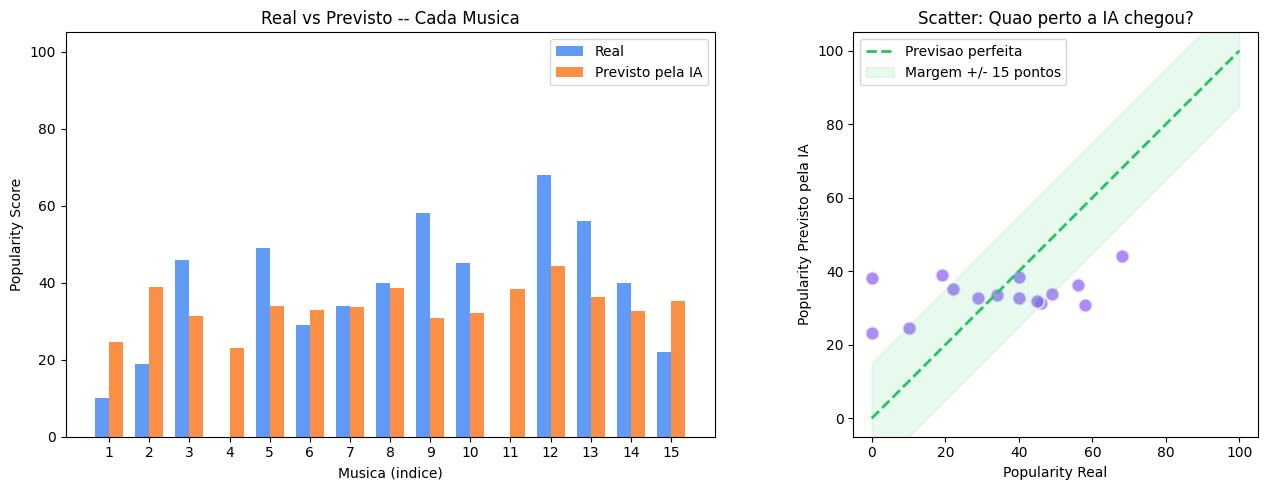


Se todos os pontos estivessem na linha verde, a IA seria perfeita!
Pontos dentro da faixa verde = previsao razoavel (erro <= 15 pontos)


In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Grafico 1: Barras lado a lado ---
x = range(len(comparacao))
width = 0.35
bars_real = axes[0].bar([i - width/2 for i in x], comparacao["Real"], width,
                         label="Real", color="#3b82f6", alpha=0.8)
bars_pred = axes[0].bar([i + width/2 for i in x], comparacao["Previsto"], width,
                         label="Previsto pela IA", color="#f97316", alpha=0.8)

axes[0].set_xlabel("Musica (indice)")
axes[0].set_ylabel("Popularity Score")
axes[0].set_title("Real vs Previsto -- Cada Musica")
axes[0].set_xticks(x)
axes[0].set_xticklabels([str(i+1) for i in x])
axes[0].legend()
axes[0].set_ylim(0, 105)

# --- Grafico 2: Scatter (pontos) ---
axes[1].scatter(comparacao["Real"], comparacao["Previsto"],
                c="#8b5cf6", s=100, alpha=0.7, edgecolors="white", linewidth=1.5)

# Linha de previsao perfeita (diagonal)
axes[1].plot([0, 100], [0, 100], "--", color="#22c55e", linewidth=2, label="Previsao perfeita")

# Faixa de margem (+/- 15 pontos)
axes[1].fill_between([0, 100], [0-15, 100-15], [0+15, 100+15],
                      alpha=0.1, color="#22c55e", label="Margem +/- 15 pontos")

axes[1].set_xlabel("Popularity Real")
axes[1].set_ylabel("Popularity Previsto pela IA")
axes[1].set_title("Scatter: Quao perto a IA chegou?")
axes[1].set_xlim(-5, 105)
axes[1].set_ylim(-5, 105)
axes[1].legend(loc="upper left")
axes[1].set_aspect("equal")

plt.tight_layout()
plt.savefig(project_root / "notebooks" / "regression_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nSe todos os pontos estivessem na linha verde, a IA seria perfeita!")
print("Pontos dentro da faixa verde = previsao razoavel (erro <= 15 pontos)")
     